<a href="https://colab.research.google.com/github/abdullah-621/pandas/blob/main/session_17_tasks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv"

## Basic DataFrame

Consider the following Python dictionary data and Python list labels:

```
data = {'birds': ['Cranes', 'Cranes', 'plovers', 'spoonbills', 'spoonbills', 'Cranes', 'plovers', 'Cranes', 'spoonbills', 'spoonbills', 'Cranes'],
        'age': [3.5, 4, 1.5, np.nan, 6, 3, 5.5, np.nan, 8, 4, 3.5], 'visits': [2, 4, 3, 4, 3, 4, 2, 2, 3, 2, 2],
        'priority': ['yes', 'yes', 'no', np.nan, 'no', 'no', 'no', 'yes', 'no', 'no','yes']}
```
```
labels = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k']
```

###`Q-1:`
i. Create a DataFrame birds from the above dictionary data which has the index labels.

ii. Display basic information about the dataFrame.

iii. Show Alternate rows of the dataframe.

In [ ]:
# code here

###`Q-2:`
i. Show only rows [1st, 3rd, 7th] from columns ['bird', 'age']

ii. Select rows where the number of visits is less than 4.

In [ ]:
# code here

###`Q-3:`
i. Select all rows with nan values in age and visits column.

ii. Fill nan with respective series mode value.

In [ ]:
# code here

###`Q-4`
i. Find the total number of visits of the bird Cranes

ii. Find the number of each type of birds in dataframe.

iii. Print no of duplicate rows

iv. Drop Duplicates rows and make this changes permanent. Show dataframe after changes.

In [ ]:
# code here

##Question on IPL Data

IPL Data Link :  https://drive.google.com/file/d/1yKVUuexl6lIKuFQy7uIPgDgXhJ0L4SIg/view?usp=share_link

https://www.kaggle.com/datasets/vora1011/ipl-2008-to-2021-all-match-dataset?select=IPL_Matches_2008_2022.csv

Download ipl matches 2008-2022 file.

###`Q-5:` In IPL matches dataset some teams name has changed.
You will have to consider them as same.
```
'Delhi Capitals' formerly as 'Delhi Daredevils'
'Punjab Kings' formerly as 'Kings XI Punjab'
'Rising Pune Supergiant' formerly as 'Rising Pune Supergiants'
```
You need to make changes accordingly. Consider current name for each teams.

Be careful Gujrat Titans and Gujrat Lions are different teams.

In [57]:
# code here
import pandas as pd
import numpy as np

ipl = pd.read_csv('ipl-matches.csv')

###`Q-6` Write a code which can display the bar chart of top 5 teams who have played maximum number of matches in the IPL.
>  Hint: Be careful the data is divided in 2 different cols(Team 1 and Team 2)


                           Team  Total_match
10               Mumbai Indians          231
16  Royal Challengers Bangalore          226
8         Kolkata Knight Riders          223
0           Chennai Super Kings          208
13             Rajasthan Royals          192
6               Kings XI Punjab          190
3              Delhi Daredevils          161
17          Sunrisers Hyderabad          152
1               Deccan Chargers           75
2                Delhi Capitals           63
11                Pune Warriors           46
4                 Gujarat Lions           30
12                 Punjab Kings           28
5                Gujarat Titans           16
14       Rising Pune Supergiant           16
9          Lucknow Super Giants           15
7          Kochi Tuskers Kerala           14
15      Rising Pune Supergiants           14


<Axes: >

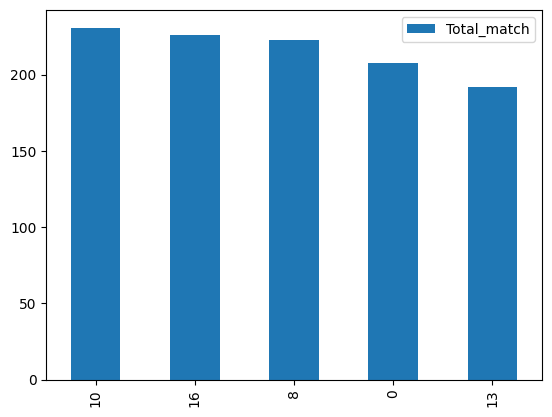

In [64]:
# code here
# code here

total_team1 = ipl['Team1'].unique()
total_team2 = ipl['Team2'].unique()

all_team = np.unique(np.concatenate((total_team1, total_team2)))


new_df = {}

for team in all_team:

  mask1 = (ipl['Team1'] == team)
  mask2 = (ipl['Team2'] == team)
  total_match = mask1.sum() + mask2.sum()
  new_df[team] = total_match

matches_per_team = pd.DataFrame(list(new_df.items()), columns=['Team','Total_match'])

matches_per_team.sort_values(by='Total_match', ascending=False, inplace=True)
print(matches_per_team)

top5 = matches_per_team.sort_values(by='Total_match', ascending=False).head(5)
top5.plot(kind='bar')



                           Team  Total_match
10               Mumbai Indians          231
16  Royal Challengers Bangalore          226
8         Kolkata Knight Riders          223
0           Chennai Super Kings          208
13             Rajasthan Royals          192
6               Kings XI Punjab          190
3              Delhi Daredevils          161
17          Sunrisers Hyderabad          152
1               Deccan Chargers           75
2                Delhi Capitals           63
11                Pune Warriors           46
4                 Gujarat Lions           30
12                 Punjab Kings           28
5                Gujarat Titans           16
14       Rising Pune Supergiant           16
9          Lucknow Super Giants           15
7          Kochi Tuskers Kerala           14
15      Rising Pune Supergiants           14


<Axes: xlabel='Team'>

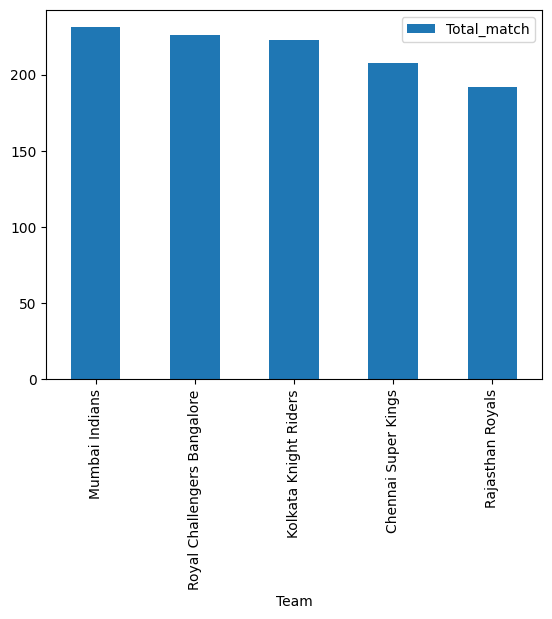

In [119]:
# code here

total_team1 = ipl['Team1'].unique()
total_team2 = ipl['Team2'].unique()

all_team = np.unique(np.concatenate((total_team1, total_team2)))


new_df = {
    'Team' : [],
    'Total_match':[]
}

for team in all_team:

  mask1 = (ipl['Team1'] == team)
  mask2 = (ipl['Team2'] == team)
  total_match = mask1.sum() + mask2.sum()
  new_df['Team'].append(team)
  new_df['Total_match'].append(total_match)

# matches_per_team = pd.DataFrame(list(new_df.items()), columns=['Team','Total_match'])
matches_per_team = pd.DataFrame(new_df)

matches_per_team.sort_values(by='Total_match', ascending=False, inplace=True)
print(matches_per_team)

top5 = matches_per_team.sort_values(by='Total_match', ascending=False).head(5).set_index('Team')
top5.plot(kind='bar')



###`Q-7:` Player who got Most no. of player of the match award playing against Mumbai Indians.
> Just for this question assume player of the match award is given to players from winning team. Although this is true in most of the cases.


In [89]:
# code here

mi_matches = ipl[(ipl['Team1'] == 'Mumbai Indians') | (ipl['Team2'] == 'Mumbai Indians')]
mi_matches

# againest_mi = mi_matches['WinningTeam']
# print(againest_mi)

player_of_match = mi_matches['Player_of_Match'].value_counts()
print(player_of_match.head(5))



Player_of_Match
RG Sharma       16
KA Pollard      14
AT Rayudu        8
JJ Bumrah        8
SR Tendulkar     8
Name: count, dtype: int64


Player_of_Match
RG Sharma    16
Name: count, dtype: int64


###`Q-8:` Team1 vs Team2 Dashbord
Create a function which will take two string(name of two teams) as input. Show win Loss record between them and player getting most player of the match award in matches between these two teams.
```
team1_vs_team2('Kolkata Knight Riders','Chennai Super Kings')
```

In [111]:
# code here
def team1_vs_team2(team1, team2):
  between = ((ipl['Team1'] == team1) & (ipl['Team2'] == team2))| ((ipl['Team1'] == team2) & (ipl['Team2'] == team1))

  matches = ipl[between].copy()
  # matches['LowserTeam'] = team1 if ipl['WinningTeam'] == team2 else team1
  matches['LowserTeam'] = np.where(matches['WinningTeam'] == team1, team2, team1)
  return matches[['Team1','Team2','LowserTeam','Player_of_Match']]


matches = team1_vs_team2('Kolkata Knight Riders','Chennai Super Kings')
matches
# print(matches['LowserTeam'].value_counts())

,Team1,Team2,LowserTeam,Player_of_Match
73,Chennai Super Kings,Kolkata Knight Riders,Chennai Super Kings,UT Yadav
74,Chennai Super Kings,Kolkata Knight Riders,Kolkata Knight Riders,F du Plessis
95,Kolkata Knight Riders,Chennai Super Kings,Kolkata Knight Riders,RA Jadeja
119,Chennai Super Kings,Kolkata Knight Riders,Kolkata Knight Riders,F du Plessis
145,Kolkata Knight Riders,Chennai Super Kings,Kolkata Knight Riders,RD Gaikwad
173,Kolkata Knight Riders,Chennai Super Kings,Chennai Super Kings,RA Tripathi
224,Kolkata Knight Riders,Chennai Super Kings,Kolkata Knight Riders,Imran Tahir
231,Kolkata Knight Riders,Chennai Super Kings,Kolkata Knight Riders,DL Chahar
281,Chennai Super Kings,Kolkata Knight Riders,Chennai Super Kings,SP Narine
309,Kolkata Knight Riders,Chennai Super Kings,Kolkata Knight Riders,SW Billings


from matplotlib import pyplot as plt
import seaborn as sns
matches.groupby('Team1').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
matches.groupby('Team2').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
matches.groupby('LowserTeam').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['Team2'].value_counts()
    for x_label, grp in matches.groupby('Team1')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('Team1')
_ = plt.ylabel('Team2')

from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['LowserTeam'].value_counts()
    for x_label, grp in matches.groupby('Team2')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('Team2')
_ = plt.ylabel('LowserTeam')

### `Q-9:` Find out the top 7 cities where the matches of Kolkata Knight Riders are played frequently and plot the result as bar chart.

*`.plot(kind = "bar")` can help you to plot the bar chart. Also you can learn more about this method from [here](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html)*



<Axes: xlabel='Venue'>

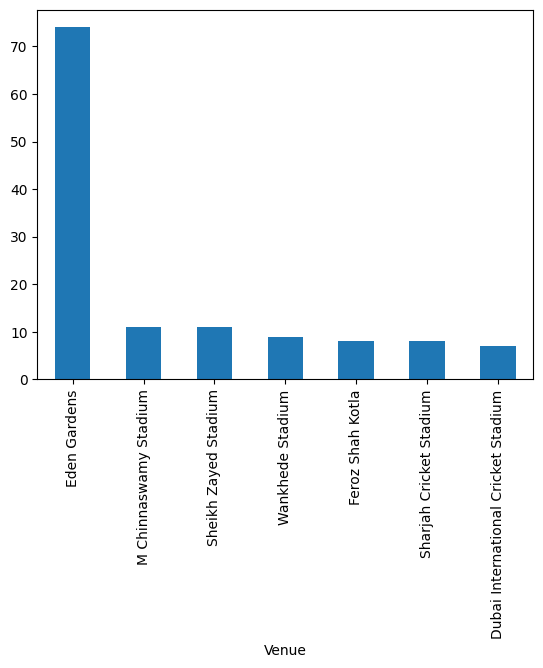

In [117]:
# code here
matches = ipl[(ipl['Team1'] == 'Kolkata Knight Riders') | (ipl['Team2'] == 'Kolkata Knight Riders')]
mask = matches['Venue'].value_counts().head(7)
mask.plot(kind='bar')


### `Q-10:` Find out the average margin for the team Mumbai Indians for only the session 2011.

In [130]:
# code here
matches = ipl[(ipl['Team1'] == 'Mumbai Indians') | (ipl['Team2'] == 'Mumbai Indians')]

matches_MI = matches['Margin']
matches['Margin'] = matches['Margin'].mean()
mask = ipl[ipl['Season'] == 2011]
mask

/tmp/ipython-input-3568489542.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  matches['Margin'] = matches['Margin'].mean()


,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2


In [127]:
ipl

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon
2,1312198,Kolkata,2022-05-25,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,N,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough
3,1312197,Kolkata,2022-05-24,2022,Qualifier 1,Rajasthan Royals,Gujarat Titans,"Eden Gardens, Kolkata",Gujarat Titans,field,N,Gujarat Titans,Wickets,7.0,NaN,DA Miller,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",BNJ Oxenford,VK Sharma
4,1304116,Mumbai,2022-05-22,2022,70,Sunrisers Hyderabad,Punjab Kings,"Wankhede Stadium, Mumbai",Sunrisers Hyderabad,bat,N,Punjab Kings,Wickets,5.0,NaN,Harpreet Brar,"['PK Garg', 'Abhishek Sharma', 'RA Tripathi', ...","['JM Bairstow', 'S Dhawan', 'M Shahrukh Khan',...",AK Chaudhary,NA Patwardhan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
945,335986,Kolkata,2008-04-20,2007/08,4,Kolkata Knight Riders,Deccan Chargers,Eden Gardens,Deccan Chargers,bat,N,Kolkata Knight Riders,Wickets,5.0,NaN,DJ Hussey,"['WP Saha', 'BB McCullum', 'RT Ponting', 'SC G...","['AC Gilchrist', 'Y Venugopal Rao', 'VVS Laxma...",BF Bowden,K Hariharan
946,335985,Mumbai,2008-04-20,2007/08,5,Mumbai Indians,Royal Challengers Bangalore,Wankhede Stadium,Mumbai Indians,bat,N,Royal Challengers Bangalore,Wickets,5.0,NaN,MV Boucher,"['L Ronchi', 'ST Jayasuriya', 'DJ Thornely', '...","['S Chanderpaul', 'R Dravid', 'LRPL Taylor', '...",SJ Davis,DJ Harper
947,335984,Delhi,2008-04-19,2007/08,3,Delhi Daredevils,Rajasthan Royals,Feroz Shah Kotla,Rajasthan Royals,bat,N,Delhi Daredevils,Wickets,9.0,NaN,MF Maharoof,"['G Gambhir', 'V Sehwag', 'S Dhawan', 'MK Tiwa...","['T Kohli', 'YK Pathan', 'SR Watson', 'M Kaif'...",Aleem Dar,GA Pratapkumar
948,335983,Chandigarh,2008-04-19,2007/08,2,Kings XI Punjab,Chennai Super Kings,"Punjab Cricket Association Stadium, Mohali",Chennai Super Kings,bat,N,Chennai Super Kings,Runs,33.0,NaN,MEK Hussey,"['K Goel', 'JR Hopes', 'KC Sangakkara', 'Yuvra...","['PA Patel', 'ML Hayden', 'MEK Hussey', 'MS Dh...",MR Benson,SL Shastri
